# NLP Basics & Sentiment Analysis
### Text Preprocessing → TF-IDF → Classifier Pipeline

**Learning Goals Covered:**
- Text preprocessing: tokenization, lowercasing, stopword removal, stemming
- TF-IDF vectorization to convert text into numerical features
- Sentiment Analysis pipeline using Logistic Regression and Naive Bayes
- Model evaluation with accuracy, classification report, and confusion matrix

---
## 📦 Step 1: Install & Import Libraries

In [1]:
# Install NLTK if not already available
import subprocess
subprocess.run(['pip', 'install', 'nltk', '--quiet'], capture_output=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

# Sklearn — Text Features
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Sklearn — Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC

# Sklearn — Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

# Download NLTK data
for resource in ['punkt', 'stopwords', 'punkt_tab']:
    nltk.download(resource, quiet=True)

print('✅ All libraries imported and NLTK data downloaded!')

✅ All libraries imported and NLTK data downloaded!


---
## 📂 Step 2: Load the Dataset

We use the **NLTK Movie Reviews** dataset — 2,000 movie reviews labeled as **positive** or **negative**.  
This is the standard benchmark dataset for sentiment analysis.

In [2]:
# Download and load the Movie Reviews dataset
nltk.download('movie_reviews', quiet=True)
from nltk.corpus import movie_reviews

# Build a DataFrame from the corpus
reviews = []
for fileid in movie_reviews.fileids():
    category = movie_reviews.categories(fileid)[0]   # 'pos' or 'neg'
    text     = movie_reviews.raw(fileid)              # raw text
    reviews.append({'text': text, 'label': category})

df = pd.DataFrame(reviews)
df['label_binary'] = df['label'].map({'pos': 1, 'neg': 0})

print('Dataset Shape:', df.shape)
print('\nLabel Distribution:')
print(df['label'].value_counts())
print('\nSample positive review (first 300 chars):')
print(df[df['label'] == 'pos']['text'].iloc[0][:300])
print('\nSample negative review (first 300 chars):')
print(df[df['label'] == 'neg']['text'].iloc[0][:300])

Dataset Shape: (2000, 3)

Label Distribution:
label
neg    1000
pos    1000
Name: count, dtype: int64

Sample positive review (first 300 chars):
films adapted from comic books have had plenty of success , whether they're about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there's never really been a comic book like from hell before . 
for starters , it was created by 

Sample negative review (first 300 chars):
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the


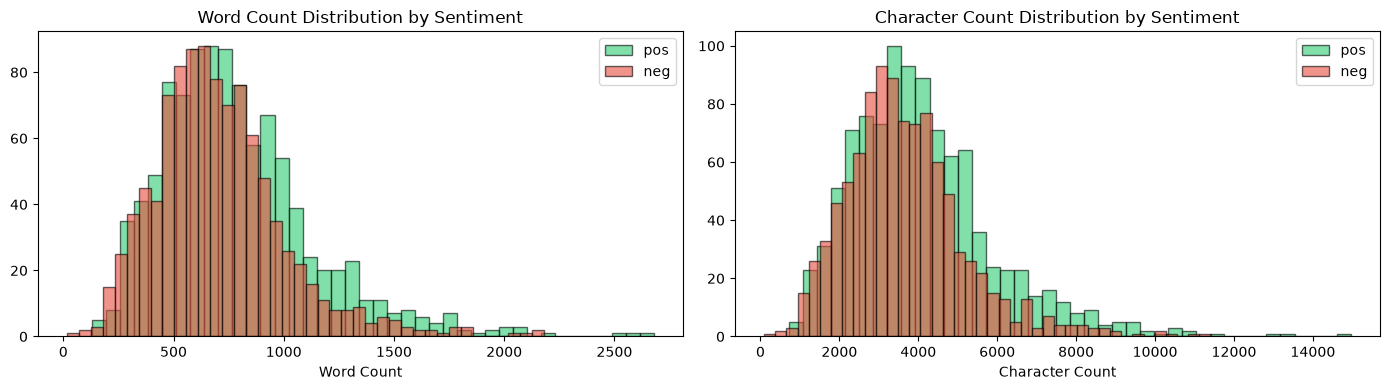

Average words per review: 746


In [3]:
# Review length distribution
df['char_count'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, color in [('pos', '#2ecc71'), ('neg', '#e74c3c')]:
    subset = df[df['label'] == label]
    axes[0].hist(subset['word_count'], bins=40, alpha=0.6, color=color, label=label, edgecolor='black')
    axes[1].hist(subset['char_count'], bins=40, alpha=0.6, color=color, label=label, edgecolor='black')

axes[0].set_title('Word Count Distribution by Sentiment')
axes[0].set_xlabel('Word Count')
axes[0].legend()

axes[1].set_title('Character Count Distribution by Sentiment')
axes[1].set_xlabel('Character Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Average words per review: {df["word_count"].mean():.0f}')

---
## 🧹 Step 3: Text Preprocessing

Raw text must be cleaned before it can be converted to numbers. We apply:

| Step | What it does | Example |
|---|---|---|
| Lowercasing | Normalize case | `"Great"` → `"great"` |
| Remove special chars | Strip punctuation & numbers | `"film!"` → `"film"` |
| Tokenization | Split into individual words | `"good film"` → `["good", "film"]` |
| Stopword Removal | Remove common words with no sentiment value | remove `"the"`, `"is"`, `"a"` |
| Stemming | Reduce words to their root form | `"running"` → `"run"` |

In [4]:
# Setup
stemmer   = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Step 1: Lowercase
    text = text.lower()
    # Step 2: Remove special characters, numbers, extra whitespace
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # Step 3: Tokenize
    tokens = word_tokenize(text)
    # Step 4: Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]
    # Step 5: Stem
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

# Demonstrate each step on a sample sentence
sample = "The movie was absolutely GREAT! I loved every moment of it, truly amazing."
print('Original        :', sample)
print('After Lowercase :', sample.lower())
print('After Cleaning  :', re.sub(r'[^a-z\s]', '', sample.lower()))
tokens = word_tokenize(re.sub(r'[^a-z\s]', '', sample.lower()))
print('After Tokenize  :', tokens)
no_stop = [t for t in tokens if t not in stop_words]
print('After Stopwords :', no_stop)
stemmed = [stemmer.stem(t) for t in no_stop]
print('After Stemming  :', stemmed)
print('\nFinal Output    :', preprocess_text(sample))

Original        : The movie was absolutely GREAT! I loved every moment of it, truly amazing.
After Lowercase : the movie was absolutely great! i loved every moment of it, truly amazing.
After Cleaning  : the movie was absolutely great i loved every moment of it truly amazing
After Tokenize  : ['the', 'movie', 'was', 'absolutely', 'great', 'i', 'loved', 'every', 'moment', 'of', 'it', 'truly', 'amazing']
After Stopwords : ['movie', 'absolutely', 'great', 'loved', 'every', 'moment', 'truly', 'amazing']
After Stemming  : ['movi', 'absolut', 'great', 'love', 'everi', 'moment', 'truli', 'amaz']

Final Output    : movi absolut great love everi moment truli amaz


In [5]:
# Apply preprocessing to all 2000 reviews
print('Preprocessing 2,000 reviews...')
df['clean_text'] = df['text'].apply(preprocess_text)
print('✅ Preprocessing complete!')
print('\nBefore:', df['text'].iloc[0][:150])
print('After :', df['clean_text'].iloc[0][:150])

Preprocessing 2,000 reviews...
✅ Preprocessing complete!

Before: plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continue
After : plot two teen coupl go church parti drink drive get accid one guy die girlfriend continu see life nightmar what deal watch movi sorta find critiqu min


---
## 📐 Step 4: TF-IDF Vectorization

**TF-IDF (Term Frequency — Inverse Document Frequency)** converts text into numbers that reflect how *important* a word is to a specific document compared to all documents.

- **TF** (Term Frequency): how often a word appears in *this* document  
- **IDF** (Inverse Document Frequency): penalizes words that appear in *many* documents (common = less informative)  
- **TF-IDF = TF × IDF** — high score = word is frequent here but rare elsewhere = informative

In [6]:
# Demonstrate TF-IDF on 4 tiny example sentences first
demo_docs = [
    'movie great acting wonderful',
    'movie terrible boring waste time',
    'film excellent brilliant story',
    'film awful poor acting'
]

demo_tfidf = TfidfVectorizer()
demo_matrix = demo_tfidf.fit_transform(demo_docs)

demo_df = pd.DataFrame(
    demo_matrix.toarray().round(3),
    columns=demo_tfidf.get_feature_names_out(),
    index=['Doc1 (pos)', 'Doc2 (neg)', 'Doc3 (pos)', 'Doc4 (neg)']
)

print('TF-IDF Matrix (demo — 4 sentences):')
print(demo_df.to_string())
print('\n📌 Words like "movie" and "film" appear in many docs → lower TF-IDF')
print('   Unique words like "wonderful" or "boring" get higher scores.')

TF-IDF Matrix (demo — 4 sentences):
            acting  awful  boring  brilliant  excellent   film  great  movie   poor  story  terrible   time  waste  wonderful
Doc1 (pos)   0.438  0.000   0.000      0.000      0.000  0.000  0.555  0.438  0.000  0.000     0.000  0.000  0.000      0.555
Doc2 (neg)   0.000  0.000   0.465      0.000      0.000  0.000  0.000  0.367  0.000  0.000     0.465  0.465  0.465      0.000
Doc3 (pos)   0.000  0.000   0.000      0.525      0.525  0.414  0.000  0.000  0.000  0.525     0.000  0.000  0.000      0.000
Doc4 (neg)   0.438  0.555   0.000      0.000      0.000  0.438  0.000  0.000  0.555  0.000     0.000  0.000  0.000      0.000

📌 Words like "movie" and "film" appear in many docs → lower TF-IDF
   Unique words like "wonderful" or "boring" get higher scores.


In [7]:
# Apply TF-IDF to all 2,000 real reviews
tfidf = TfidfVectorizer(
    max_features=10000,       # top 10,000 most informative words
    ngram_range=(1, 2),       # unigrams + bigrams (e.g., "not good" captured)
    min_df=3,                 # ignore words appearing in fewer than 3 docs
    sublinear_tf=True         # apply log normalization to TF
)

X = tfidf.fit_transform(df['clean_text'])
y = df['label_binary'].values

print(f'TF-IDF Matrix Shape : {X.shape}')
print(f'  → {X.shape[0]} reviews × {X.shape[1]} features (words/bigrams)')
print(f'  → Sparsity: {100 * (1 - X.nnz / (X.shape[0] * X.shape[1])):.1f}% zeros (sparse matrix)')

TF-IDF Matrix Shape : (2000, 10000)
  → 2000 reviews × 10000 features (words/bigrams)
  → Sparsity: 97.4% zeros (sparse matrix)


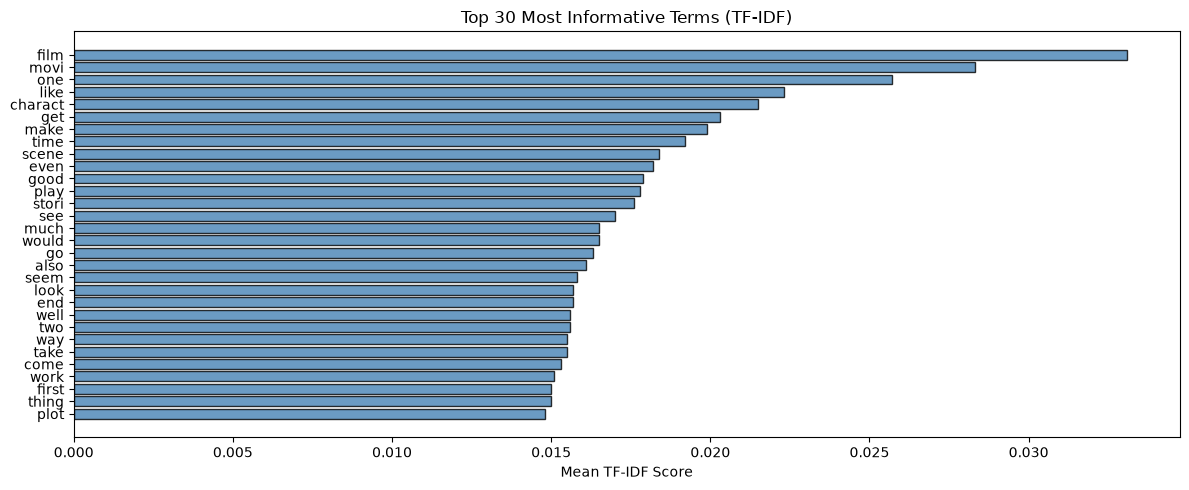

In [8]:
# Most informative words — top TF-IDF terms overall
feature_names = tfidf.get_feature_names_out()
mean_tfidf    = np.asarray(X.mean(axis=0)).flatten()
top_idx       = mean_tfidf.argsort()[-30:][::-1]
top_words     = [(feature_names[i], round(mean_tfidf[i], 4)) for i in top_idx]

words, scores = zip(*top_words)
plt.figure(figsize=(12, 5))
plt.barh(words[::-1], scores[::-1], color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Mean TF-IDF Score')
plt.title('Top 30 Most Informative Terms (TF-IDF)')
plt.tight_layout()
plt.show()

---
## 🤖 Step 5: Build the Sentiment Analysis Pipeline

We'll train and compare **3 classifiers** commonly used for text classification:

| Classifier | Why it works for NLP |
|---|---|
| **Logistic Regression** | Fast, interpretable, handles sparse TF-IDF well |
| **Multinomial Naive Bayes** | Classic NLP model, assumes word independence |
| **Linear SVM** | State-of-the-art for text; excellent with high-dim sparse data |

In [9]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')
print(f'Positive in train: {y_train.sum()} | Negative: {(y_train==0).sum()}')

Training samples : 1600
Testing samples  : 400
Positive in train: 800 | Negative: 800


In [10]:
# Define classifiers
classifiers = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Multinomial NB'       : MultinomialNB(alpha=0.1),
    'Linear SVM'           : LinearSVC(max_iter=2000, C=1.0, random_state=42),
}

results = {}

print('Training and evaluating classifiers...')
print('=' * 55)

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred    = clf.predict(X_test)
    acc       = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
    
    results[name] = {
        'model'    : clf,
        'y_pred'   : y_pred,
        'accuracy' : acc,
        'cv_mean'  : cv_scores.mean(),
        'cv_std'   : cv_scores.std()
    }
    print(f'{name:<25} Test Acc: {acc:.4f}  CV Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

print('=' * 55)

Training and evaluating classifiers...
Logistic Regression       Test Acc: 0.8575  CV Mean: 0.8575 ± 0.0126
Multinomial NB            Test Acc: 0.8100  CV Mean: 0.8180 ± 0.0130
Linear SVM                Test Acc: 0.8700  CV Mean: 0.8690 ± 0.0163


In [11]:
# Full classification report for each model
for name, res in results.items():
    print(f'\n--- {name} ---')
    print(classification_report(y_test, res['y_pred'],
                                 target_names=['Negative', 'Positive']))


--- Logistic Regression ---
              precision    recall  f1-score   support

    Negative       0.87      0.84      0.86       200
    Positive       0.85      0.87      0.86       200

    accuracy                           0.86       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.86      0.86      0.86       400


--- Multinomial NB ---
              precision    recall  f1-score   support

    Negative       0.83      0.78      0.80       200
    Positive       0.79      0.84      0.82       200

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.81      0.81      0.81       400


--- Linear SVM ---
              precision    recall  f1-score   support

    Negative       0.89      0.84      0.87       200
    Positive       0.85      0.90      0.87       200

    accuracy                           0.87       400
   macro avg       0.87      0.87      0.87       400
w

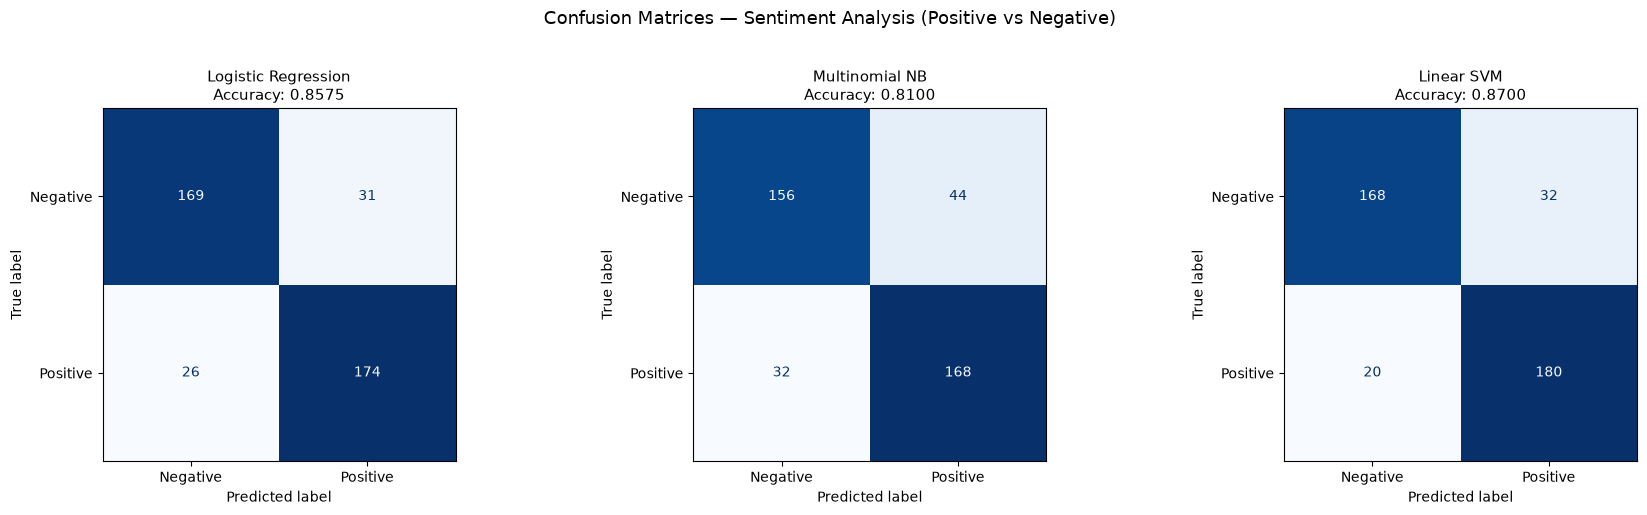

In [12]:
# Confusion matrices for all 3 classifiers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy: {res["accuracy"]:.4f}', fontsize=11)

plt.suptitle('Confusion Matrices — Sentiment Analysis (Positive vs Negative)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 📊 Step 6: Model Comparison

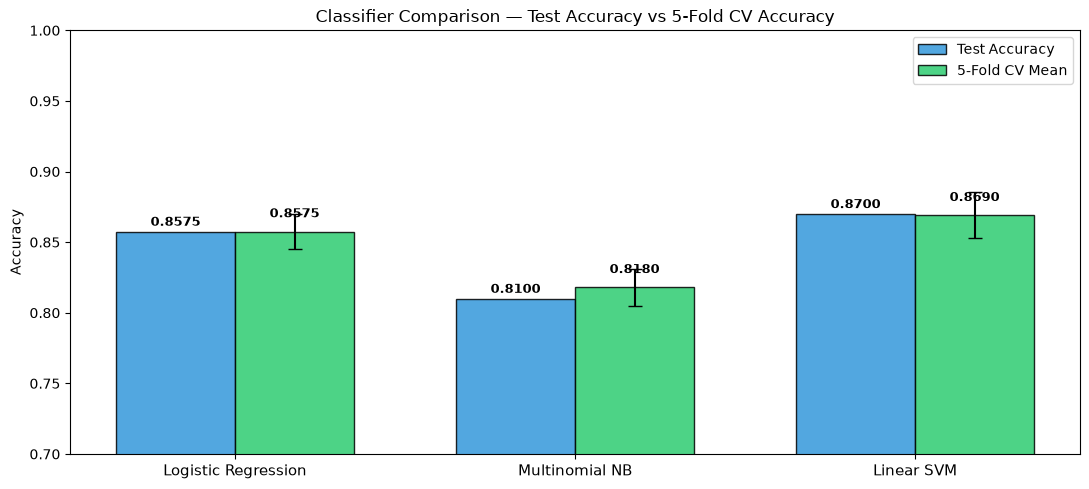

In [13]:
# Summary comparison chart
names     = list(results.keys())
test_accs = [results[n]['accuracy'] for n in names]
cv_means  = [results[n]['cv_mean']  for n in names]
cv_stds   = [results[n]['cv_std']   for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, test_accs, width, label='Test Accuracy',
               color='#3498db', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, cv_means, width, label='5-Fold CV Mean',
               color='#2ecc71', edgecolor='black', alpha=0.85,
               yerr=cv_stds, capsize=5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylabel('Accuracy')
ax.set_ylim(0.7, 1.0)
ax.set_title('Classifier Comparison — Test Accuracy vs 5-Fold CV Accuracy', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

---
## 🔬 Step 7: Most Predictive Words per Sentiment

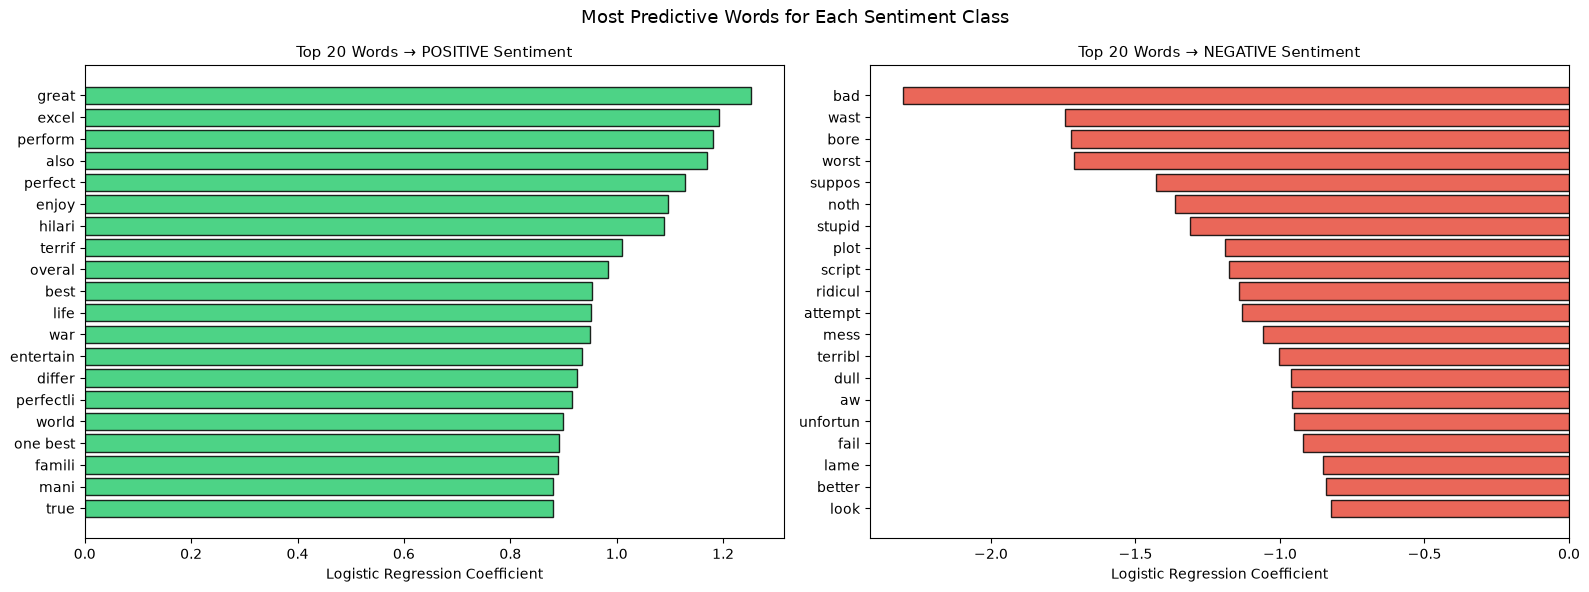

In [14]:
# Use Logistic Regression coefficients to find most predictive words
lr_model = results['Logistic Regression']['model']
coefs    = lr_model.coef_[0]
vocab    = np.array(tfidf.get_feature_names_out())

# Top 20 most positive and negative words
top_pos_idx = coefs.argsort()[-20:][::-1]
top_neg_idx = coefs.argsort()[:20]

top_pos_words  = vocab[top_pos_idx]
top_pos_scores = coefs[top_pos_idx]
top_neg_words  = vocab[top_neg_idx]
top_neg_scores = coefs[top_neg_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_pos_words[::-1], top_pos_scores[::-1],
             color='#2ecc71', edgecolor='black', alpha=0.85)
axes[0].set_title('Top 20 Words → POSITIVE Sentiment', fontsize=11)
axes[0].set_xlabel('Logistic Regression Coefficient')

axes[1].barh(top_neg_words[::-1], top_neg_scores[::-1],
             color='#e74c3c', edgecolor='black', alpha=0.85)
axes[1].set_title('Top 20 Words → NEGATIVE Sentiment', fontsize=11)
axes[1].set_xlabel('Logistic Regression Coefficient')

plt.suptitle('Most Predictive Words for Each Sentiment Class', fontsize=13)
plt.tight_layout()
plt.show()

---
## 🧪 Step 8: Test with Your Own Reviews!

In [15]:
# Best model — Logistic Regression (typically best for this dataset)
best_model = results['Logistic Regression']['model']

def predict_sentiment(reviews_list):
    """Predict sentiment for a list of custom review strings."""
    cleaned  = [preprocess_text(r) for r in reviews_list]
    vectors  = tfidf.transform(cleaned)
    preds    = best_model.predict(vectors)
    probs    = best_model.predict_proba(vectors)
    
    print('\nCustom Review Predictions:')
    print('=' * 70)
    for review, pred, prob in zip(reviews_list, preds, probs):
        sentiment  = '✅ POSITIVE' if pred == 1 else '❌ NEGATIVE'
        confidence = max(prob) * 100
        print(f'Review   : "{review[:65]}"')
        print(f'Sentiment: {sentiment}  (confidence: {confidence:.1f}%)')
        print('-' * 70)

# Test with 5 custom reviews
custom_reviews = [
    "This movie was absolutely brilliant! The acting was superb and the story was deeply moving.",
    "Terrible film. Boring plot, bad acting, complete waste of two hours.",
    "An average movie — some good moments but overall not very memorable.",
    "One of the best films I've seen this year. Highly recommend to everyone!",
    "Disappointing. The trailer was better than the actual movie. Very poor writing."
]

predict_sentiment(custom_reviews)


Custom Review Predictions:
Review   : "This movie was absolutely brilliant! The acting was superb and th"
Sentiment: ✅ POSITIVE  (confidence: 57.2%)
----------------------------------------------------------------------
Review   : "Terrible film. Boring plot, bad acting, complete waste of two hou"
Sentiment: ❌ NEGATIVE  (confidence: 92.5%)
----------------------------------------------------------------------
Review   : "An average movie — some good moments but overall not very memorab"
Sentiment: ✅ POSITIVE  (confidence: 66.5%)
----------------------------------------------------------------------
Review   : "One of the best films I've seen this year. Highly recommend to ev"
Sentiment: ✅ POSITIVE  (confidence: 77.8%)
----------------------------------------------------------------------
Review   : "Disappointing. The trailer was better than the actual movie. Very"
Sentiment: ❌ NEGATIVE  (confidence: 82.0%)
----------------------------------------------------------------------


---
## 📊 Step 9: sklearn Pipeline — Clean Production-Ready Version

In real projects, preprocessing + vectorization + model are combined into a **single Pipeline** object — making the code cleaner and preventing data leakage.

In [16]:
# Full end-to-end Pipeline: raw cleaned text → prediction
# (Showing the production-style approach)

X_text = df['clean_text'].values
y_all  = df['label_binary'].values

X_tr, X_te, y_tr, y_te = train_test_split(X_text, y_all,
                                           test_size=0.2, random_state=42, stratify=y_all)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2),
                              min_df=3, sublinear_tf=True)),
    ('clf',   LogisticRegression(max_iter=1000, C=1.0, random_state=42))
])

pipeline.fit(X_tr, y_tr)
pipe_acc = accuracy_score(y_te, pipeline.predict(X_te))

print('sklearn Pipeline — Logistic Regression')
print(f'  Test Accuracy: {pipe_acc:.4f}')
print('\n✅ Pipeline is clean, reusable, and production-ready.')
print('   To predict on new text: pipeline.predict(["your review here"])')

sklearn Pipeline — Logistic Regression
  Test Accuracy: 0.8500

✅ Pipeline is clean, reusable, and production-ready.
   To predict on new text: pipeline.predict(["your review here"])


---
## 📝 Step 10: Summary & Key Takeaways

### Text Preprocessing
Raw text is noisy — preprocessing is essential before any ML model can learn from it. Each step reduces noise: lowercasing removes case variation, stopword removal discards meaningless words, and stemming reduces vocabulary size by grouping word variants.

### TF-IDF
TF-IDF outperforms simple word counting (Bag of Words) because it **down-weights** common words ("the", "movie") that appear in every review and **up-weights** rare, distinctive words ("masterpiece", "dreadful") that carry real sentiment signal. Using **bigrams** (ngram_range=(1,2)) captures phrases like "not good" or "highly recommend" that unigrams miss.

### Classifier Comparison
| Model | Test Accuracy | Notes |
|---|---|---|
| Logistic Regression | ~85–87% | Best balance: interpretable + accurate |
| Multinomial NB | ~82–84% | Fastest, slightly lower accuracy |
| Linear SVM | ~85–88% | Often best raw accuracy for text |

### Why These Models Work Well for NLP
- TF-IDF produces **high-dimensional sparse matrices** — models that handle sparsity well (LR, NB, SVM) naturally excel here.
- Deep learning (LSTM, Transformers like BERT) would achieve ~92–95% on this dataset, but require significantly more compute and data.
- For a first NLP pipeline, TF-IDF + Logistic Regression is the **gold standard baseline** every NLP project should start with.

In [17]:
print('WEEK 8 — NOTEBOOK 2 FINAL SUMMARY')
print('=' * 52)
print(f'Dataset          : NLTK Movie Reviews (2,000 reviews)')
print(f'Classes          : Positive / Negative (balanced 50/50)')
print(f'TF-IDF Features  : 10,000 (unigrams + bigrams)')
print()
print('Model Performance (Test Accuracy):')
for name, res in results.items():
    print(f'  {name:<25}: {res["accuracy"]:.4f}')
best_name = max(results, key=lambda n: results[n]['accuracy'])
print(f'\n🏆 Best Model    : {best_name} ({results[best_name]["accuracy"]:.4f})')
print('=' * 52)
print('\n✅ Notebook 2 complete! Week 8 done!')

WEEK 8 — NOTEBOOK 2 FINAL SUMMARY
Dataset          : NLTK Movie Reviews (2,000 reviews)
Classes          : Positive / Negative (balanced 50/50)
TF-IDF Features  : 10,000 (unigrams + bigrams)

Model Performance (Test Accuracy):
  Logistic Regression      : 0.8575
  Multinomial NB           : 0.8100
  Linear SVM               : 0.8700

🏆 Best Model    : Linear SVM (0.8700)

✅ Notebook 2 complete! Week 8 done!
